# Lab 4: Enhancing the Bike Sharing System

Welcome to **Lab 4** of the Modeling & Simulation course! In this laboratory session, we will build upon the foundations laid in the previous labs to enhance our bike-sharing system simulation. This lab introduces the concept of **time slot-specific probabilities**, allowing you to model varying bike usage patterns throughout the day. Additionally, you will implement bike maintenance and downtime, develop a rebalancing mechanism, track customer satisfaction, and undertake a **graded assignment** to design and implement a comprehensive simulation project.

---

## Table of Contents

1. [Recap of Previous Labs](#recap)
2. [Introduction to Time Slot-Specific Probabilities](#time-slots)
   - [Understanding Time Slots](#understanding-time-slots)
3. [Implementing Time Slot-Specific Probabilities](#implementing-time-slots)
   - [Defining Time Slots](#defining-time-slots)
4. [Graded Assignment Overview](#assignment)

---

## <a name="recap"></a>1. Recap of Previous Labs

### Lab 1: Python Introduction
- Gained proficiency in Python programming.
- Learned fundamental programming concepts such as variables, data types, control structures, functions, and basic I/O operations.

### Lab 2: Basic Bike Sharing System Modeling
- Developed a simplified bike-sharing system using Python classes.
- Modeled entities such as stations, bikes, and trips.
- Implemented basic trip generation and analyzed system behavior over a short period.

### Lab 3: Introduction to SimPy
- Introduced SimPy, a discrete-event simulation library in Python.
- Reimplemented the bike-sharing system using SimPy constructs like environments, processes, and resources.
- Explored extensions including variable trip durations, rebalancing strategies, and customer satisfaction tracking.

---

## <a name="time-slots"></a>2. Introduction to Time Slot-Specific Probabilities

In real-world scenarios, bike usage varies throughout the day. To simulate this variability, we introduce **time slot-specific probabilities**. This enhancement allows the simulation to reflect different demand levels during various periods, such as morning rush hours and midday.

### <a name="understanding-time-slots"></a>Understanding Time Slots

- **Time Slots:** Defined periods within a day where bike trip probabilities differ.
- **Recurring Pattern:** Time slots repeat every simulated day, enabling multi-day simulations.
- **Example Time Slots:**
  - **Morning Start (0-120 minutes):** Initial hours with increasing demand.
  - **Midday (120-720 minutes):** Peak hours with stable high demand.

### <a name="mapping-time"></a>Mapping Simulation Time to Real-Time

To create realistic simulations, map simulation minutes to actual day times.

- **Simulation Start Time:** 6:00 AM
- **Morning Start:** 6:00 AM - 8:00 AM (0-120 minutes)
- **Midday:** 8:00 AM - 6:00 PM (120-720 minutes)
- **Simulation Duration:** 20 days (12 hours/day) → 14400 minutes

---

## <a name="implementing-time-slots"></a>3. Implementing Time Slot-Specific Probabilities

### <a name="defining-time-slots"></a>Defining Time Slots

Define time slots with specific trip probability matrices within a single day. Use the modulo operation to map the current simulation time to the appropriate time slot.

```python
# Define time slots for a single day
time_slots = [
    {
        'name': 'morning_start',
        'start': 0,       # 0 minutes into the day (6:00 AM)
        'end': 120,       # 2 hours
        'prob_matrix': {
            ('A', 'B'): 0.4,
            ('B', 'A'): 0.6,
            ('A', 'C'): 0.2,
            ('C', 'A'): 0.5,
            ('B', 'C'): 0.3,
            ('C', 'B'): 0.4,
            ('A', 'D'): 0.3,
            ('D', 'A'): 0.2,
        }
    },
    {
        'name': 'midday',
        'start': 120,      # 2 hours into the day (8:00 AM)
        'end': 720,        # 12 hours total (6:00 PM)
        'prob_matrix': {
            ('A', 'B'): 0.2,
            ('B', 'A'): 0.3,
            ('A', 'C'): 0.1,
            ('C', 'A'): 0.2,
            ('B', 'C'): 0.25,
            ('C', 'B'): 0.35,
            ('A', 'D'): 0.15,
            ('D', 'A'): 0.25,
        }
    }
    # Add more time slots if needed
]

# Define default probability matrix if no slot matches
default_prob_matrix = {
    ('A', 'B'): 0.05,
    ('B', 'A'): 0.05,
    ('A', 'C'): 0.05,
    ('C', 'A'): 0.05,
    ('B', 'C'): 0.05,
    ('C', 'B'): 0.05,
    ('A', 'D'): 0.05,
    ('D', 'A'): 0.05,
}


In [14]:
# import simpy
# import random
# import matplotlib.pyplot as plt

# # Define time slots for a single day (12 hours = 720 minutes)
# time_slots = [
#     {
#         'name': 'morning_start',
#         'start': 0,       # 0 minutes into the day (6:00 AM)
#         'end': 120,       # 2 hours (8:00 AM)
#         'prob_matrix': {
#             ('A', 'B'): 0.4,
#             ('B', 'A'): 0.6,
#             ('A', 'C'): 0.2,
#             ('C', 'A'): 0.5,
#             ('B', 'C'): 0.3,
#             ('C', 'B'): 0.4,
#             ('A', 'D'): 0.3,
#             ('D', 'A'): 0.2,
#         }
#     },
#     {
#         'name': 'midday',
#         'start': 120,      # 2 hours into the day (8:00 AM)
#         'end': 720,        # 12 hours total (6:00 PM)
#         'prob_matrix': {
#             ('A', 'B'): 0.2,
#             ('B', 'A'): 0.3,
#             ('A', 'C'): 0.1,
#             ('C', 'A'): 0.2,
#             ('B', 'C'): 0.25,
#             ('C', 'B'): 0.35,
#             ('A', 'D'): 0.15,
#             ('D', 'A'): 0.25,
#         }
#     }
# ]

# # Default probability matrix for times outside defined slots
# default_prob_matrix = {
#     ('A', 'B'): 0.05,
#     ('B', 'A'): 0.05,
#     ('A', 'C'): 0.05,
#     ('C', 'A'): 0.05,
#     ('B', 'C'): 0.05,
#     ('C', 'B'): 0.05,
#     ('A', 'D'): 0.05,
#     ('D', 'A'): 0.05,
# }

# # Station class from Lab 3
# class Station:
#     def __init__(self, env, name, capacity, init_bikes):
#         self.env = env
#         self.name = name
#         self.capacity = capacity
#         self.bikes = simpy.Container(env, init=init_bikes, capacity=capacity)
#         self.broken_bikes = 0

# # Function to get current probability matrix based on time slot
# def get_current_prob_matrix(env, time_slots, default_prob_matrix, day_duration=720):
#     """
#     Returns the probability matrix for the current simulation time.
#     Uses modulo to handle multi-day simulations.
#     """
#     time_in_day = env.now % day_duration
    
#     for slot in time_slots:
#         if slot['start'] <= time_in_day < slot['end']:
#             return slot['prob_matrix']
    
#     return default_prob_matrix

# # Bike trip with maintenance/failure possibility
# def bike_trip(env, from_station, to_station, unhappy_tracker, failure_prob=0.05):
#     """
#     Simulates a bike trip with variable duration and failure probability.
#     """
#     trip_duration = random.randint(5, 20)  # 5-20 minutes trip
    
#     if from_station.bikes.level > 0:
#         yield from_station.bikes.get(1)
#     else:
#         if unhappy_tracker is not None:
#             unhappy_tracker['pickup_failed'] += 1
#         return

#     # Simulate the trip
#     yield env.timeout(trip_duration)
    
#     # Check if bike breaks during trip
#     if random.uniform(0, 1) < failure_prob:
#         from_station.broken_bikes += 1
#         return  # Bike is broken, goes to maintenance
    
#     # Try to return bike
#     if to_station.bikes.level < to_station.capacity:
#         yield to_station.bikes.put(1)
#     else:
#         if unhappy_tracker is not None:
#             unhappy_tracker['return_failed'] += 1
#         # Return to original station
#         yield env.timeout(trip_duration)
#         if from_station.bikes.level < from_station.capacity:
#             yield from_station.bikes.put(1)

# # Trip generation with time-slot specific probabilities
# def generate_trips(env, stations, time_slots, default_prob_matrix, unhappy_tracker, day_duration=720):
#     station_map = {s.name: s for s in stations}
    
#     while True:
#         # Get current probability matrix
#         prob_matrix = get_current_prob_matrix(env, time_slots, default_prob_matrix, day_duration)
        
#         # Generate trips based on current probabilities
#         for (from_name, to_name), prob in prob_matrix.items():
#             if from_name in station_map and to_name in station_map:
#                 if random.uniform(0, 1) < prob:
#                     from_station = station_map[from_name]
#                     to_station = station_map[to_name]
#                     env.process(bike_trip(env, from_station, to_station, unhappy_tracker))
        
#         yield env.timeout(1)  # Check every minute

# # Bike maintenance process
# def repair_bikes(env, stations, repair_interval=30, repair_rate=0.5):
#     while True:
#         yield env.timeout(repair_interval)
        
#         for station in stations:
#             if station.broken_bikes > 0:
#                 bikes_to_repair = max(1, int(station.broken_bikes * repair_rate))
#                 bikes_to_repair = min(bikes_to_repair, station.broken_bikes)
                
#                 # Only repair if there's space at the station
#                 available_space = station.capacity - station.bikes.level
#                 bikes_repaired = min(bikes_to_repair, available_space)
                
#                 if bikes_repaired > 0:
#                     yield station.bikes.put(bikes_repaired)
#                     station.broken_bikes -= bikes_repaired

# # Rebalancing mechanism
# def rebalance_stations(env, stations, rebalance_interval=20):
#     while True:
#         yield env.timeout(rebalance_interval)
        
#         total_bikes = sum(s.bikes.level for s in stations)
#         avg_bikes = total_bikes / len(stations)
        
#         overstocked = [s for s in stations if s.bikes.level > avg_bikes + 2]
#         understocked = [s for s in stations if s.bikes.level < avg_bikes - 2]
        
#         for from_station in overstocked:
#             for to_station in understocked:
#                 excess = int(from_station.bikes.level - avg_bikes)
#                 deficit = int(avg_bikes - to_station.bikes.level)
#                 bikes_to_move = min(excess, deficit, 3)
                
#                 if bikes_to_move > 0:
#                     available_space = to_station.capacity - to_station.bikes.level
#                     bikes_to_move = min(bikes_to_move, available_space)
                    
#                     if bikes_to_move > 0:
#                         yield from_station.bikes.get(bikes_to_move)
#                         yield to_station.bikes.put(bikes_to_move)

# def monitor_system(env, stations, bike_levels, broken_bikes_log, unhappy_log, unhappy_tracker):

#     while True:
#         for station in stations:
#             bike_levels[station.name].append((env.now, station.bikes.level))
        
#         total_broken = sum(s.broken_bikes for s in stations)
#         broken_bikes_log.append((env.now, total_broken))
        
#         total_unhappy = unhappy_tracker['pickup_failed'] + unhappy_tracker['return_failed']
#         unhappy_log.append((env.now, total_unhappy))
        
#         yield env.timeout(1)

# # Setup environment and stations for testing
# env = simpy.Environment()

# stations = [
#     Station(env, 'A', capacity=12, init_bikes=6),
#     Station(env, 'B', capacity=12, init_bikes=6),
#     Station(env, 'C', capacity=12, init_bikes=6),
#     Station(env, 'D', capacity=12, init_bikes=6),
# ]

# unhappy_tracker = {'pickup_failed': 0, 'return_failed': 0}
# bike_levels = {s.name: [] for s in stations}
# broken_bikes_log = []
# unhappy_log = []

# # Start processes
# env.process(generate_trips(env, stations, time_slots, default_prob_matrix, unhappy_tracker))
# env.process(repair_bikes(env, stations, repair_interval=30, repair_rate=0.5))
# env.process(rebalance_stations(env, stations, rebalance_interval=20))
# env.process(monitor_system(env, stations, bike_levels, broken_bikes_log, unhappy_log, unhappy_tracker))

# # Run simulation for 2 days (12h per day -> 720 minutes/day)
# simulation_minutes = 2 * 720
# env.run(until=simulation_minutes)

# # Print final station states and unhappy counts
# for s in stations:
#     print(f"Station {s.name}: bikes={s.bikes.level}, broken={s.broken_bikes}")

# print("Unhappy pickups:", unhappy_tracker['pickup_failed'])
# print("Unhappy returns:", unhappy_tracker['return_failed'])
# print("Total unhappy:", unhappy_tracker['pickup_failed'] + unhappy_tracker['return_failed'])

# # Simple plots of bike levels over time
# plt.figure(figsize=(10, 5))
# for name, records in bike_levels.items():
#     if records:
#         times, levels = zip(*records)
#         plt.plot(times, levels, label=name)
# plt.xlabel("Time (minutes)")
# plt.ylabel("Available bikes")
# plt.title("Bike levels over time")
# plt.legend()
# plt.grid(True)
# plt.show()

# # Plot broken bikes and unhappy log
# if broken_bikes_log:
#     times_b, broken = zip(*broken_bikes_log)
#     plt.figure(figsize=(10, 3))
#     plt.plot(times_b, broken, label="Broken bikes (total)")
#     plt.xlabel("Time (minutes)")
#     plt.ylabel("Broken bikes")
#     plt.title("Broken bikes over time")
#     plt.grid(True)
#     plt.show()

# if unhappy_log:
#     times_u, unhappy_vals = zip(*unhappy_log)
#     plt.figure(figsize=(10, 3))
#     plt.plot(times_u, unhappy_vals, label="Cumulative unhappy")
#     plt.xlabel("Time (minutes)")
#     plt.ylabel("Unhappy count")
#     plt.title("Unhappy customers over time")
#     plt.grid(True)
#     plt.show()

## <a name="assignment"></a>Graded Assignment Overview

Design and implement an enhanced bike-sharing system simulation using **SimPy**, incorporating advanced features to model a realistic and complex environment. Your simulation should build upon the concepts learned in previous labs and include the following components:

---

Your simulation must include the following elements:

### 1. Multiple Stations:

- **Minimum of Four stations** with varying capacities and initial bike counts.
- Each station should have a unique name, capacity, and initial number of bikes.

### 2. Time-Dependent Trip Probabilities:

- Implement trip probabilities that change based on different time slots (e.g., morning start, midday).
- Define at least **two distinct time slots** with different probability matrices.
- Ensure that time slots are **recurring daily** over the simulation period.

### 3. Bike Maintenance and Downtime:

- Model bike failures with a specified failure probability during trips.
- Implement a repair process that handles broken bikes, making them unavailable until repaired. The implementation details are up to your imagination.
- Track and report the number of bikes under maintenance.

### 4. Rebalancing Mechanism:

- Develop a rebalancing strategy to redistribute bikes between stations based on current demand and bike levels.
- Rebalancing should occur at regular intervals (e.g., every 20 minutes) and follow defined criteria.

### 5. Customer Satisfaction Tracking:

- Track the number of **unhappy customers** who cannot rent a bike due to unavailability.
- Track the number of **unhappy customers** who cannot return a bike due to full stations.

### 6. Data Collection and Visualization:

- Collect data on **bike levels** at each station over time.
- Collect data on **broken bikes** and maintenance activities.
- Collect data on **customer satisfaction** metrics.
- Generate plots to visualize:
  - **Bike levels** at each station over time.
  - **Number of bikes under maintenance**.
  - **Customer satisfaction metrics** (e.g., unhappy customers over time).

### 7. Simulation:

- Allow the simulation to run for a configurable duration (e.g., **20 days**).
- Parameters such as the number of stations, capacities, initial bikes, trip probabilities, maintenance rates, rebalancing intervals, and simulation duration should be easily adjustable.
- Simulate and observe the system with various parameters.

---

#### (Optional) Money Earning Mechanism:

- Introduce a system where the bike-sharing service earns **money based on bike rentals** (e.g., per hour rented).
- Track and report **total earnings** over the simulation period.

## What to Look For in Your Simulations

The primary objective of this lab is to enable you to create a realistic and dynamic simulation of a bike-sharing system that accounts for daily usage patterns, system maintenance, and operational strategies. Things to look for:

* Bike Availability: Assess how well the rebalancing mechanism maintains adequate bike levels across stations.
* Maintenance Impact: Evaluate the effect of bike failures on system performance and customer satisfaction.
* Customer Satisfaction: Analyze the number of unhappy customers and identify patterns or causes.

Write down a couple of observations from your simulations to accompany the presentation of your system.

## Grading

You will present your work in the upcoming laboratory, showing your system implementation and 1-3 simulations that you ran. The simulations should be accompanied by visual plots and you are encouraged to present any interesting observations about your system (e.g. with environment setup X the customer dissatisfaction drops significantly when increasing the rebalancing frequency to value y).

The project grade will be determined by the grade of completion of your system (how much of the project task has been implemented), as well as your understanding of it. The latter will be assessed through some basic questions about your model/system/simulations.

*Note: Where not strongly specified, you are free to design a subsystem/idea however you find best fit, e.g. points 2, 3 and 4 can have many different subsystem designs. There is no one correct way to do it.

In [15]:
import simpy
import random
import matplotlib.pyplot as plt
import statistics

# ============================================================================
# 1. STATION CLASS
# ============================================================================
class Station:
    def __init__(self, env, name, capacity, init_bikes):
        self.env = env
        self.name = name
        self.capacity = capacity
        self.bikes = simpy.Container(env, init=init_bikes, capacity=capacity)
        self.broken_bikes = 0

In [16]:
# ============================================================================
# 2. TIME SLOT DEFINITIONS (Requirement 2: Time-Dependent Probabilities)
# ============================================================================
time_slots = [
    {
        'name': 'morning_rush',
        'start': 0,       # 6:00 AM
        'end': 120,       # 8:00 AM (2 hours)
        'prob_matrix': {
            ('A', 'B'): 0.5,   # High commute to work
            ('B', 'A'): 0.2,
            ('A', 'C'): 0.4,
            ('C', 'A'): 0.15,
            ('A', 'D'): 0.35,
            ('D', 'A'): 0.1,
            ('B', 'C'): 0.3,
            ('C', 'B'): 0.2,
            ('B', 'D'): 0.25,
            ('D', 'B'): 0.15,
            ('C', 'D'): 0.2,
            ('D', 'C'): 0.25,
        }
    },
    {
        'name': 'midday',
        'start': 120,     # 8:00 AM
        'end': 600,       # 4:00 PM (8 hours)
        'prob_matrix': {
            ('A', 'B'): 0.15,  # Moderate, distributed traffic
            ('B', 'A'): 0.15,
            ('A', 'C'): 0.12,
            ('C', 'A'): 0.12,
            ('A', 'D'): 0.1,
            ('D', 'A'): 0.1,
            ('B', 'C'): 0.18,
            ('C', 'B'): 0.18,
            ('B', 'D'): 0.13,
            ('D', 'B'): 0.13,
            ('C', 'D'): 0.15,
            ('D', 'C'): 0.15,
        }
    },
    {
        'name': 'evening_rush',
        'start': 600,     # 4:00 PM
        'end': 720,       # 6:00 PM (2 hours)
        'prob_matrix': {
            ('A', 'B'): 0.2,   # Return home pattern
            ('B', 'A'): 0.5,
            ('A', 'C'): 0.15,
            ('C', 'A'): 0.4,
            ('A', 'D'): 0.1,
            ('D', 'A'): 0.35,
            ('B', 'C'): 0.2,
            ('C', 'B'): 0.3,
            ('B', 'D'): 0.15,
            ('D', 'B'): 0.25,
            ('C', 'D'): 0.25,
            ('D', 'C'): 0.2,
        }
    }
]

default_prob_matrix = {
    ('A', 'B'): 0.05,
    ('B', 'A'): 0.05,
    ('A', 'C'): 0.05,
    ('C', 'A'): 0.05,
    ('A', 'D'): 0.05,
    ('D', 'A'): 0.05,
    ('B', 'C'): 0.05,
    ('C', 'B'): 0.05,
    ('B', 'D'): 0.05,
    ('D', 'B'): 0.05,
    ('C', 'D'): 0.05,
    ('D', 'C'): 0.05,
}

In [17]:
# ============================================================================
# 3. HELPER FUNCTION: Get Current Probability Matrix
# ============================================================================
def get_current_prob_matrix(env, time_slots, default_prob_matrix, day_duration=720):
    """Returns probability matrix based on current time slot."""
    time_in_day = env.now % day_duration
    
    for slot in time_slots:
        if slot['start'] <= time_in_day < slot['end']:
            return slot['prob_matrix']
    
    return default_prob_matrix

# ============================================================================
# 4. BIKE TRIP PROCESS (Requirement 3: Maintenance, Requirement 5: Tracking)
# ============================================================================
def bike_trip(env, from_station, to_station, unhappy_tracker, failure_prob=0.03, 
              rental_cost_per_minute=0.1, earnings_tracker=None, debug=False, 
              all_stations=None, system_tracker=None):
    """
    Simulates a bike trip with detailed tracking.
    If both origin and destination are full, tries to find any available station.
    """
    trip_duration = random.randint(5, 25)

    # Try to rent a bike
    if from_station.bikes.level > 0:
        yield from_station.bikes.get(1)
        # start tracking this trip as in-transit
        tid = None
        if system_tracker is not None:
            system_tracker.setdefault('in_transit', 0)
            system_tracker.setdefault('in_transit_details', [])
            system_tracker.setdefault('next_trip_id', 1)
            tid = system_tracker['next_trip_id']
            system_tracker['next_trip_id'] += 1
            system_tracker['in_transit'] += 1
            system_tracker['in_transit_details'].append({
                'id': tid,
                'from': from_station.name,
                'to': to_station.name,
                'target': to_station.name,
                'depart': env.now,
                'last_update': env.now,
                'state': 'riding'
            })

            def _set_state(state, target=None):
                for d in system_tracker['in_transit_details']:
                    if d['id'] == tid:
                        d['state'] = state
                        d['last_update'] = env.now
                        if target is not None:
                            d['target'] = target
                        break

            def _finish():
                system_tracker['in_transit'] -= 1
                # remove detail entry
                for i, d in enumerate(system_tracker['in_transit_details']):
                    if d['id'] == tid:
                        system_tracker['in_transit_details'].pop(i)
                        break
        else:
            tid = None
            def _set_state(*args, **kwargs): 
                return
            def _finish(): 
                return

        if debug:
            print(f"[{env.now}] Rented bike from {from_station.name} ({from_station.bikes.level} left)")
    else:
        if unhappy_tracker is not None:
            unhappy_tracker['pickup_failed'] += 1
        return

    # Simulate the trip
    yield env.timeout(trip_duration)

    # Calculate earnings
    if earnings_tracker is not None:
        earnings = trip_duration * rental_cost_per_minute
        earnings_tracker['total_earnings'] += earnings
        earnings_tracker['completed_trips'] += 1

    # Check if bike breaks
    if random.uniform(0, 1) < failure_prob:
        to_station.broken_bikes += 1
        if system_tracker is not None:
            _set_state('broken', target=to_station.name)
            _finish()
        if debug:
            print(f"[{env.now}] Bike BROKE at {to_station.name} (broken: {to_station.broken_bikes})")
        return

    # Try to return to destination
    if to_station.bikes.level < to_station.capacity:
        yield to_station.bikes.put(1)
        if system_tracker is not None:
            _set_state('returned', target=to_station.name)
            _finish()
        if debug:
            print(f"[{env.now}] Returned bike to {to_station.name} ({to_station.bikes.level} now)")
        return

    # Destination full - unhappy customer
    if unhappy_tracker is not None:
        unhappy_tracker['return_failed'] += 1

    if debug:
        print(f"[{env.now}] {to_station.name} FULL, returning to {from_station.name}")
    if system_tracker is not None:
        _set_state('return_to_origin', target=from_station.name)

    # Try to return to origin
    yield env.timeout(trip_duration)
    if from_station.bikes.level < from_station.capacity:
        yield from_station.bikes.put(1)
        if system_tracker is not None:
            _set_state('returned_origin', target=from_station.name)
            _finish()
        if debug:
            print(f"[{env.now}] Returned to origin {from_station.name}")
        return

    # BOTH FULL - Try to find ANY station with space
    if debug:
        print(f"[{env.now}] ⚠️  BOTH FULL! Searching for alternative station...")
    if system_tracker is not None:
        _set_state('searching')

    if all_stations is not None:
        for station in all_stations:
            if station.bikes.level < station.capacity:
                # Extra travel time to alternative station (assume nearby)
                yield env.timeout(5)  # 5 minutes extra travel
                if system_tracker is not None:
                    _set_state('waiting_put', target=station.name)
                # May block if it fills up before we arrive
                yield station.bikes.put(1)
                if system_tracker is not None:
                    _set_state('returned_alt', target=station.name)
                    _finish()
                if debug:
                    print(f"[{env.now}] ✓ Found space at Station {station.name}")
                return

    # ALL STATIONS FULL - mark as broken at destination
    if debug:
        print(f"[{env.now}] 🚨 ALL STATIONS FULL! Bike abandoned as broken at {to_station.name}")
    to_station.broken_bikes += 1
    if system_tracker is not None:
        _set_state('abandoned_broken', target=to_station.name)
        _finish()

In [18]:
# ============================================================================
# 5. TRIP GENERATION (Requirement 2: Time-Dependent Probabilities)
# ============================================================================
def generate_trips(env, stations, time_slots, default_prob_matrix, unhappy_tracker, 
                   day_duration=720, earnings_tracker=None, failure_prob=0.03,
                   system_tracker=None):
    """Generates trips based on time-slot specific probabilities."""
    station_map = {s.name: s for s in stations}
    
    while True:
        prob_matrix = get_current_prob_matrix(env, time_slots, default_prob_matrix, day_duration)
        for (from_name, to_name), prob in prob_matrix.items():
            if from_name in station_map and to_name in station_map:
                adjusted_prob = prob * 0.05
                if random.uniform(0, 1) < adjusted_prob:
                    from_station = station_map[from_name]
                    to_station = station_map[to_name]
                    env.process(bike_trip(env, from_station, to_station, 
                                          unhappy_tracker, failure_prob=failure_prob,
                                          earnings_tracker=earnings_tracker,
                                          all_stations=stations,
                                          system_tracker=system_tracker))
        yield env.timeout(1)

In [19]:
# ============================================================================
# 6. MAINTENANCE PROCESS (Requirement 3: Bike Maintenance and Downtime)
# ============================================================================
def repair_bikes(env, stations, repair_interval=60, repair_capacity=0.6):
    """
    Periodically repairs broken bikes.
    - repair_interval: how often to attempt repairs (minutes)
    - repair_capacity: percentage of broken bikes that can be repaired per cycle
    """
    while True:
        yield env.timeout(repair_interval)
        
        for station in stations:
            if station.broken_bikes > 0:
                # Repair a portion of broken bikes
                bikes_to_repair = max(1, int(station.broken_bikes * repair_capacity))
                bikes_to_repair = min(bikes_to_repair, station.broken_bikes)
                
                # Try to return to the original station first
                available_space = station.capacity - station.bikes.level
                bikes_repaired_here = min(bikes_to_repair, available_space)
                
                if bikes_repaired_here > 0:
                    yield station.bikes.put(bikes_repaired_here)
                    station.broken_bikes -= bikes_repaired_here
                    bikes_to_repair -= bikes_repaired_here
                
                # If there are still bikes to repair, try other stations
                if bikes_to_repair > 0:
                    for other_station in stations:
                        if other_station != station and bikes_to_repair > 0:
                            other_space = other_station.capacity - other_station.bikes.level
                            bikes_to_move = min(bikes_to_repair, other_space)
                            
                            if bikes_to_move > 0:
                                yield other_station.bikes.put(bikes_to_move)
                                station.broken_bikes -= bikes_to_move
                                bikes_to_repair -= bikes_to_move

In [20]:
# ============================================================================
# 7. REBALANCING MECHANISM (Requirement 4: Rebalancing)
# ============================================================================
def rebalance_stations(env, stations, rebalance_interval=20, max_bikes_per_move=3):
    """
    Redistributes bikes between stations based on current levels.
    - Moves bikes from overstocked to understocked stations
    - Occurs at regular intervals
    """
    while True:
        yield env.timeout(rebalance_interval)
        
        # Calculate system average
        total_bikes = sum(s.bikes.level for s in stations)
        avg_bikes = total_bikes / len(stations)
        
        # Identify overstocked and understocked stations
        threshold = 2  # Bikes above/below average to trigger rebalancing
        overstocked = [s for s in stations if s.bikes.level > avg_bikes + threshold]
        understocked = [s for s in stations if s.bikes.level < avg_bikes - threshold]
        
        # Move bikes
        for from_station in overstocked:
            for to_station in understocked:
                excess = int(from_station.bikes.level - avg_bikes)
                deficit = int(avg_bikes - to_station.bikes.level)
                bikes_to_move = min(excess, deficit, max_bikes_per_move)
                
                if bikes_to_move > 0:
                    available_space = to_station.capacity - to_station.bikes.level
                    bikes_to_move = min(bikes_to_move, available_space)
                    
                    if bikes_to_move > 0:
                        yield from_station.bikes.get(bikes_to_move)
                        yield to_station.bikes.put(bikes_to_move)

In [21]:
# ============================================================================
# 8. MONITORING PROCESS (Requirement 6: Data Collection)
# ============================================================================
def monitor_system(env, stations, bike_levels, broken_bikes_log, 
                   unhappy_log, unhappy_tracker, earnings_tracker=None, 
                   earnings_log=None):
    """
    Collects data throughout the simulation:
    - Bike levels at each station
    - Number of broken bikes
    - Unhappy customers
    - Optional: Earnings
    """
    while True:
        # Record bike levels at each station
        for station in stations:
            bike_levels[station.name].append((env.now, station.bikes.level))
        
        # Record total broken bikes
        total_broken = sum(s.broken_bikes for s in stations)
        broken_bikes_log.append((env.now, total_broken))
        
        # Record cumulative unhappy customers
        total_unhappy = unhappy_tracker['pickup_failed'] + unhappy_tracker['return_failed']
        unhappy_log.append((env.now, total_unhappy))
        
        # Record earnings (Optional)
        if earnings_tracker is not None and earnings_log is not None:
            earnings_log.append((env.now, earnings_tracker['total_earnings']))
        
        yield env.timeout(1)

In [22]:
# ============================================================================
# 9. MAIN SIMULATION FUNCTION (Requirement 7: Configurable Simulation)
# ============================================================================
def run_bike_sharing_simulation(
    duration=14400,              # 20 days * 12 hours * 60 min
    num_stations=4,              # Requirement 1: Multiple stations
    with_rebalancing=True,       # Requirement 4
    with_maintenance=True,       # Requirement 3
    rebalance_interval=20,       # Configurable
    repair_interval=60,          # Configurable
    failure_prob=0.03,           # Configurable
    enable_earnings=False        # Optional feature
):
    """
    Main simulation with all configurable parameters.
    Returns comprehensive results for analysis.
    """
    env = simpy.Environment()
    
    station_configs = [
        {'name': 'A', 'capacity': 15, 'init_bikes': 10},
        {'name': 'B', 'capacity': 12, 'init_bikes': 8},
        {'name': 'C', 'capacity': 10, 'init_bikes': 6},
        {'name': 'D', 'capacity': 8,  'init_bikes': 5},
    ]
    
    stations = [Station(env, cfg['name'], cfg['capacity'], cfg['init_bikes']) 
                for cfg in station_configs[:num_stations]]
    
    bike_levels = {station.name: [] for station in stations}
    broken_bikes_log = []
    unhappy_log = []
    unhappy_tracker = {'pickup_failed': 0, 'return_failed': 0}
    
    # Track bikes currently not in any container (on trips or waiting to put)
    system_tracker = {'in_transit': 0, 'in_transit_details': [], 'next_trip_id': 1}
    
    earnings_tracker = None
    earnings_log = []
    if enable_earnings:
        earnings_tracker = {'total_earnings': 0.0, 'completed_trips': 0}
    
    # Start all processes
    env.process(generate_trips(env, stations, time_slots, default_prob_matrix, 
                              unhappy_tracker, failure_prob=failure_prob,
                              earnings_tracker=earnings_tracker,
                              system_tracker=system_tracker))
    env.process(monitor_system(env, stations, bike_levels, broken_bikes_log, 
                              unhappy_log, unhappy_tracker, earnings_tracker, earnings_log))
    
    if with_maintenance:
        env.process(repair_bikes(env, stations, repair_interval=repair_interval))
    
    if with_rebalancing:
        env.process(rebalance_stations(env, stations, rebalance_interval=rebalance_interval))
    
    # Run simulation (Requirement 7)
    env.run(until=duration)
    
    return {
        'bike_levels': bike_levels,
        'broken_bikes': broken_bikes_log,
        'unhappy_log': unhappy_log,
        'unhappy_tracker': unhappy_tracker,
        'stations': stations,
        'earnings_tracker': earnings_tracker,
        'earnings_log': earnings_log,
        'system_tracker': system_tracker
    }


In [23]:
# ============================================================================
# 10. VISUALIZATION FUNCTION (Requirement 6: Plots)
# ============================================================================
def visualize_results(results, title_suffix=""):
    """Creates comprehensive visualization of simulation results."""
    
    fig = plt.figure(figsize=(16, 12))
    gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)
    
    # Plot 1: Bike levels at each station over time
    ax1 = fig.add_subplot(gs[0, :])
    for station_name, levels in results['bike_levels'].items():
        if levels:
            times, counts = zip(*levels)
            ax1.plot(times, counts, label=f'Station {station_name}', linewidth=2, marker='')
    ax1.set_xlabel('Time (minutes)', fontsize=12)
    ax1.set_ylabel('Number of Bikes', fontsize=12)
    ax1.set_title(f'Bike Availability at Each Station Over Time {title_suffix}', fontsize=14, fontweight='bold')
    ax1.legend(loc='best')
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Broken bikes under maintenance
    ax2 = fig.add_subplot(gs[1, 0])
    if results['broken_bikes']:
        times, counts = zip(*results['broken_bikes'])
        ax2.plot(times, counts, color='red', linewidth=2)
        ax2.fill_between(times, counts, alpha=0.3, color='red')
    ax2.set_xlabel('Time (minutes)', fontsize=12)
    ax2.set_ylabel('Number of Broken Bikes', fontsize=12)
    ax2.set_title('Bikes Under Maintenance', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    
    # Plot 3: Cumulative unhappy customers
    ax3 = fig.add_subplot(gs[1, 1])
    if results['unhappy_log']:
        times, counts = zip(*results['unhappy_log'])
        ax3.plot(times, counts, color='orange', linewidth=2)
        ax3.fill_between(times, counts, alpha=0.3, color='orange')
    ax3.set_xlabel('Time (minutes)', fontsize=12)
    ax3.set_ylabel('Cumulative Unhappy Customers', fontsize=12)
    ax3.set_title('Customer Dissatisfaction Over Time', fontsize=14, fontweight='bold')
    ax3.grid(True, alpha=0.3)
    
    # Plot 4: Final station distribution
    ax4 = fig.add_subplot(gs[2, 0])
    station_names = [s.name for s in results['stations']]
    available_bikes = [s.bikes.level for s in results['stations']]
    broken_bikes = [s.broken_bikes for s in results['stations']]
    
    x = range(len(station_names))
    ax4.bar(x, available_bikes, label='Available', color='green', alpha=0.7)
    ax4.bar(x, broken_bikes, bottom=available_bikes, label='Broken', color='red', alpha=0.7)
    ax4.set_xticks(x)
    ax4.set_xticklabels(station_names)
    ax4.set_ylabel('Number of Bikes', fontsize=12)
    ax4.set_title('Final Station Status', fontsize=14, fontweight='bold')
    ax4.legend()
    ax4.grid(True, alpha=0.3, axis='y')
    
    # Plot 5: Earnings over time (Optional)
    ax5 = fig.add_subplot(gs[2, 1])
    if results['earnings_tracker'] and results['earnings_log']:
        times, earnings = zip(*results['earnings_log'])
        ax5.plot(times, earnings, color='green', linewidth=2)
        ax5.fill_between(times, earnings, alpha=0.3, color='green')
        ax5.set_xlabel('Time (minutes)', fontsize=12)
        ax5.set_ylabel('Total Earnings ($)', fontsize=12)
        ax5.set_title('Cumulative Revenue', fontsize=14, fontweight='bold')
        ax5.grid(True, alpha=0.3)
    else:
        ax5.text(0.5, 0.5, 'Earnings tracking disabled', 
                ha='center', va='center', fontsize=14, transform=ax5.transAxes)
        ax5.set_title('Revenue (Optional Feature)', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

In [24]:
# ============================================================================
# 11. PRINT SUMMARY STATISTICS
# ============================================================================
def print_summary(results, duration):
    """Prints comprehensive summary of simulation results."""
    print(f"\n{'='*70}")
    print(f"SIMULATION SUMMARY - Duration: {duration} minutes ({duration/720:.1f} days)")
    print(f"{'='*70}")
    
    print(f"\n📊 CUSTOMER SATISFACTION:")
    print(f"  • Pickup failures:  {results['unhappy_tracker']['pickup_failed']}")
    print(f"  • Return failures:  {results['unhappy_tracker']['return_failed']}")
    print(f"  • Total unhappy:    {results['unhappy_tracker']['pickup_failed'] + results['unhappy_tracker']['return_failed']}")
    print(f"  • Unhappy per day:  {(results['unhappy_tracker']['pickup_failed'] + results['unhappy_tracker']['return_failed']) / (duration/720):.2f}")
    
    print(f"\n🚲 STATION STATUS:")
    for station in results['stations']:
        print(f"  • Station {station.name}: {station.bikes.level} available, {station.broken_bikes} broken (capacity: {station.capacity})")
    
    total_available = sum(s.bikes.level for s in results['stations'])
    total_broken = sum(s.broken_bikes for s in results['stations'])
    in_transit = results.get('system_tracker', {}).get('in_transit', 0)
    details = results.get('system_tracker', {}).get('in_transit_details', [])
    total_bikes = total_available + total_broken + in_transit
    
    print(f"\n  Total bikes: {total_available} available, {total_broken} under maintenance, {in_transit} in transit")
    print(f"  ⚠️  TOTAL IN SYSTEM: {total_bikes} (should be 29)")
    if total_bikes != 29:
        print(f"  🚨 WARNING: {29 - total_bikes} bikes have disappeared from the system!")
    
    # List in-transit trips at end
    if in_transit > 0 and details:
        print("\n🧭 In-transit trips at simulation end:")
        for d in details:
            print(f"  • Trip {d['id']}: {d['from']} -> {d['target']} (initial dest {d['to']}), "
                  f"departed t={d['depart']}, last update t={d['last_update']}, state={d['state']}")
    
    if results['earnings_tracker']:
        print(f"\n💰 FINANCIAL METRICS:")
        print(f"  • Total earnings:     ${results['earnings_tracker']['total_earnings']:.2f}")
        print(f"  • Completed trips:    {results['earnings_tracker']['completed_trips']}")
        print(f"  • Average per trip:   ${results['earnings_tracker']['total_earnings']/max(1, results['earnings_tracker']['completed_trips']):.2f}")
        print(f"  • Earnings per day:   ${results['earnings_tracker']['total_earnings']/(duration/720):.2f}")

SCENARIO 1: With Rebalancing and Maintenance

SIMULATION SUMMARY - Duration: 14400 minutes (20.0 days)

📊 CUSTOMER SATISFACTION:
  • Pickup failures:  0
  • Return failures:  113
  • Total unhappy:    113
  • Unhappy per day:  5.65

🚲 STATION STATUS:
  • Station A: 10 available, 1 broken (capacity: 15)
  • Station B: 5 available, 0 broken (capacity: 12)
  • Station C: 5 available, 0 broken (capacity: 10)
  • Station D: 6 available, 0 broken (capacity: 8)

  Total bikes: 26 available, 1 under maintenance, 2 in transit
  ⚠️  TOTAL IN SYSTEM: 29 (should be 29)

🧭 In-transit trips at simulation end:
  • Trip 1503: C -> A (initial dest A), departed t=14390, last update t=14390, state=riding
  • Trip 1504: C -> D (initial dest D), departed t=14396, last update t=14396, state=riding

💰 FINANCIAL METRICS:
  • Total earnings:     $2256.80
  • Completed trips:    1502
  • Average per trip:   $1.50
  • Earnings per day:   $112.84


C:\Users\alexc\AppData\Local\Temp\ipykernel_19528\3231539101.py:75: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


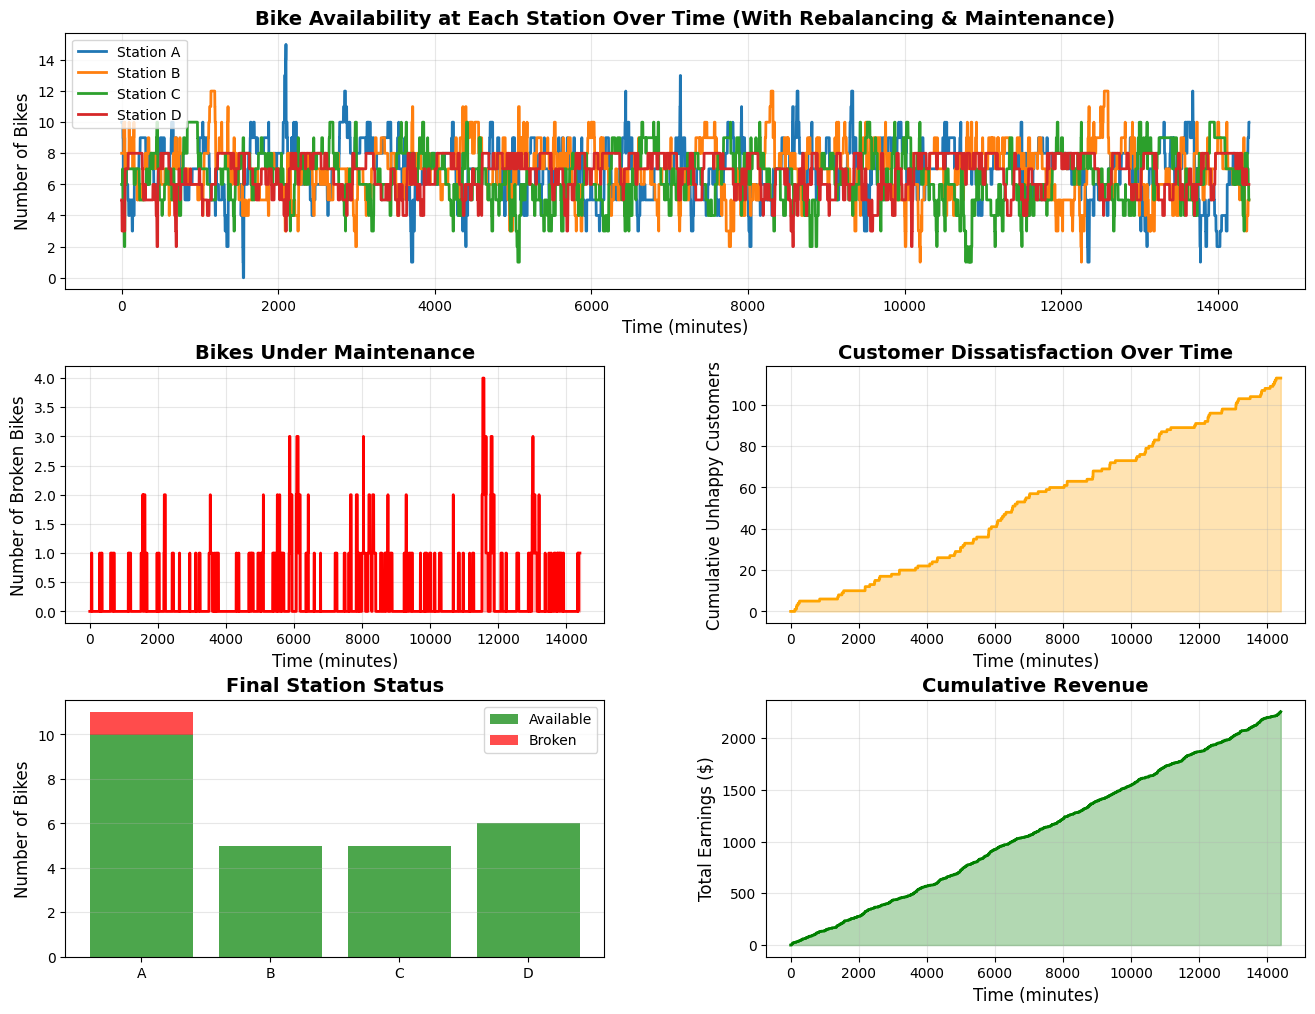


SCENARIO 2: Without Rebalancing

SIMULATION SUMMARY - Duration: 14400 minutes (20.0 days)

📊 CUSTOMER SATISFACTION:
  • Pickup failures:  77
  • Return failures:  61
  • Total unhappy:    138
  • Unhappy per day:  6.90

🚲 STATION STATUS:
  • Station A: 10 available, 1 broken (capacity: 15)
  • Station B: 11 available, 2 broken (capacity: 12)
  • Station C: 0 available, 0 broken (capacity: 10)
  • Station D: 4 available, 0 broken (capacity: 8)

  Total bikes: 25 available, 3 under maintenance, 1 in transit
  ⚠️  TOTAL IN SYSTEM: 29 (should be 29)

🧭 In-transit trips at simulation end:
  • Trip 1401: D -> B (initial dest B), departed t=14397, last update t=14397, state=riding

💰 FINANCIAL METRICS:
  • Total earnings:     $2058.80
  • Completed trips:    1400
  • Average per trip:   $1.47
  • Earnings per day:   $102.94


C:\Users\alexc\AppData\Local\Temp\ipykernel_19528\3231539101.py:75: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


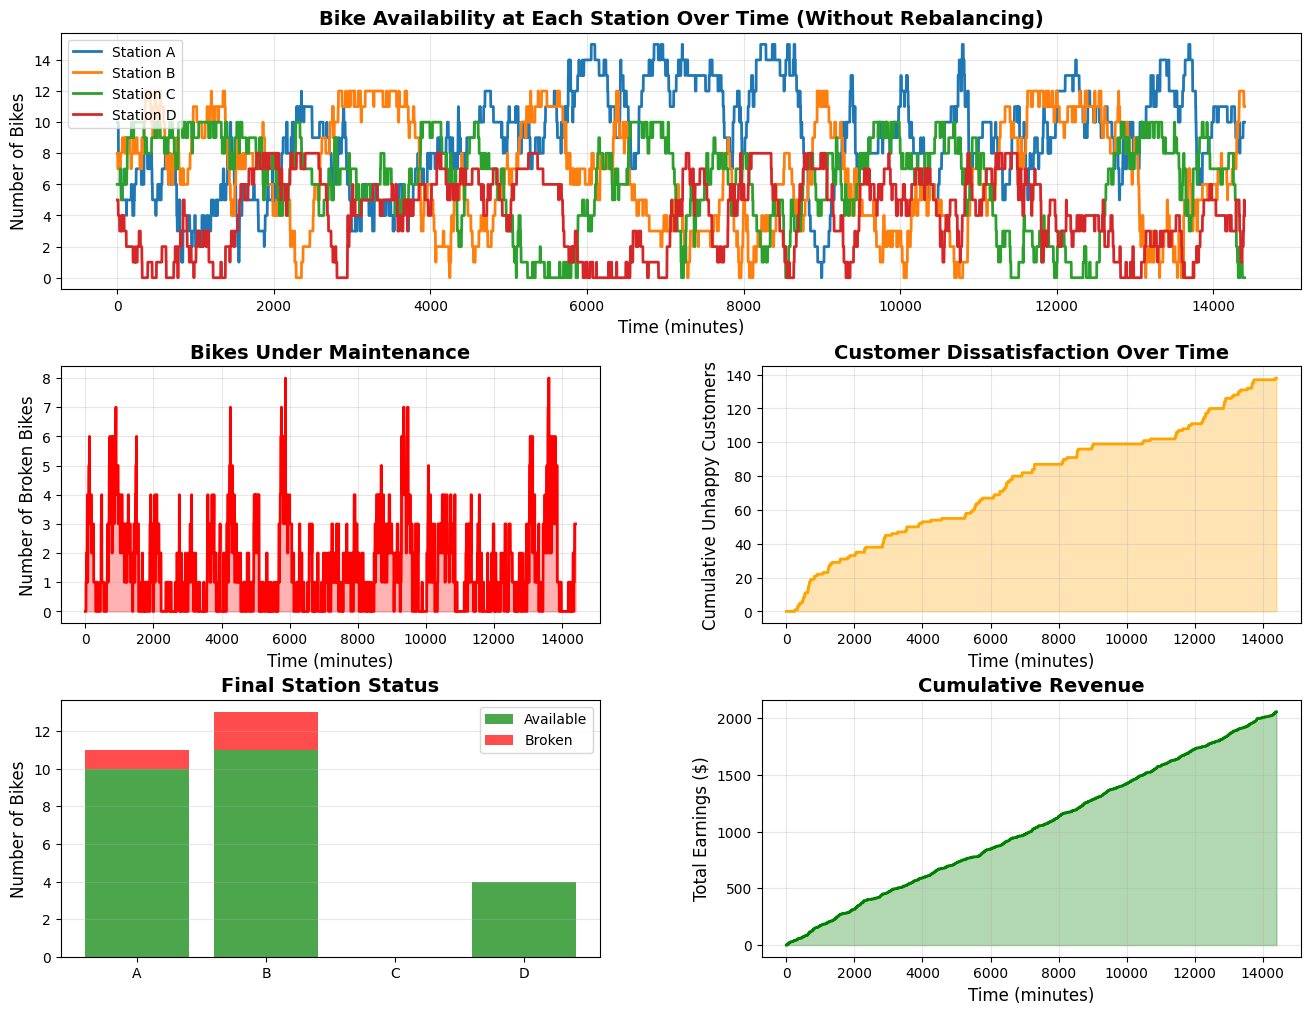


SCENARIO 3: Increased Rebalancing Frequency

SIMULATION SUMMARY - Duration: 14400 minutes (20.0 days)

📊 CUSTOMER SATISFACTION:
  • Pickup failures:  0
  • Return failures:  86
  • Total unhappy:    86
  • Unhappy per day:  4.30

🚲 STATION STATUS:
  • Station A: 9 available, 1 broken (capacity: 15)
  • Station B: 7 available, 0 broken (capacity: 12)
  • Station C: 5 available, 0 broken (capacity: 10)
  • Station D: 6 available, 0 broken (capacity: 8)

  Total bikes: 27 available, 1 under maintenance, 1 in transit
  ⚠️  TOTAL IN SYSTEM: 29 (should be 29)

🧭 In-transit trips at simulation end:
  • Trip 1528: C -> A (initial dest A), departed t=14382, last update t=14382, state=riding

💰 FINANCIAL METRICS:
  • Total earnings:     $2297.80
  • Completed trips:    1528
  • Average per trip:   $1.50
  • Earnings per day:   $114.89


C:\Users\alexc\AppData\Local\Temp\ipykernel_19528\3231539101.py:75: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


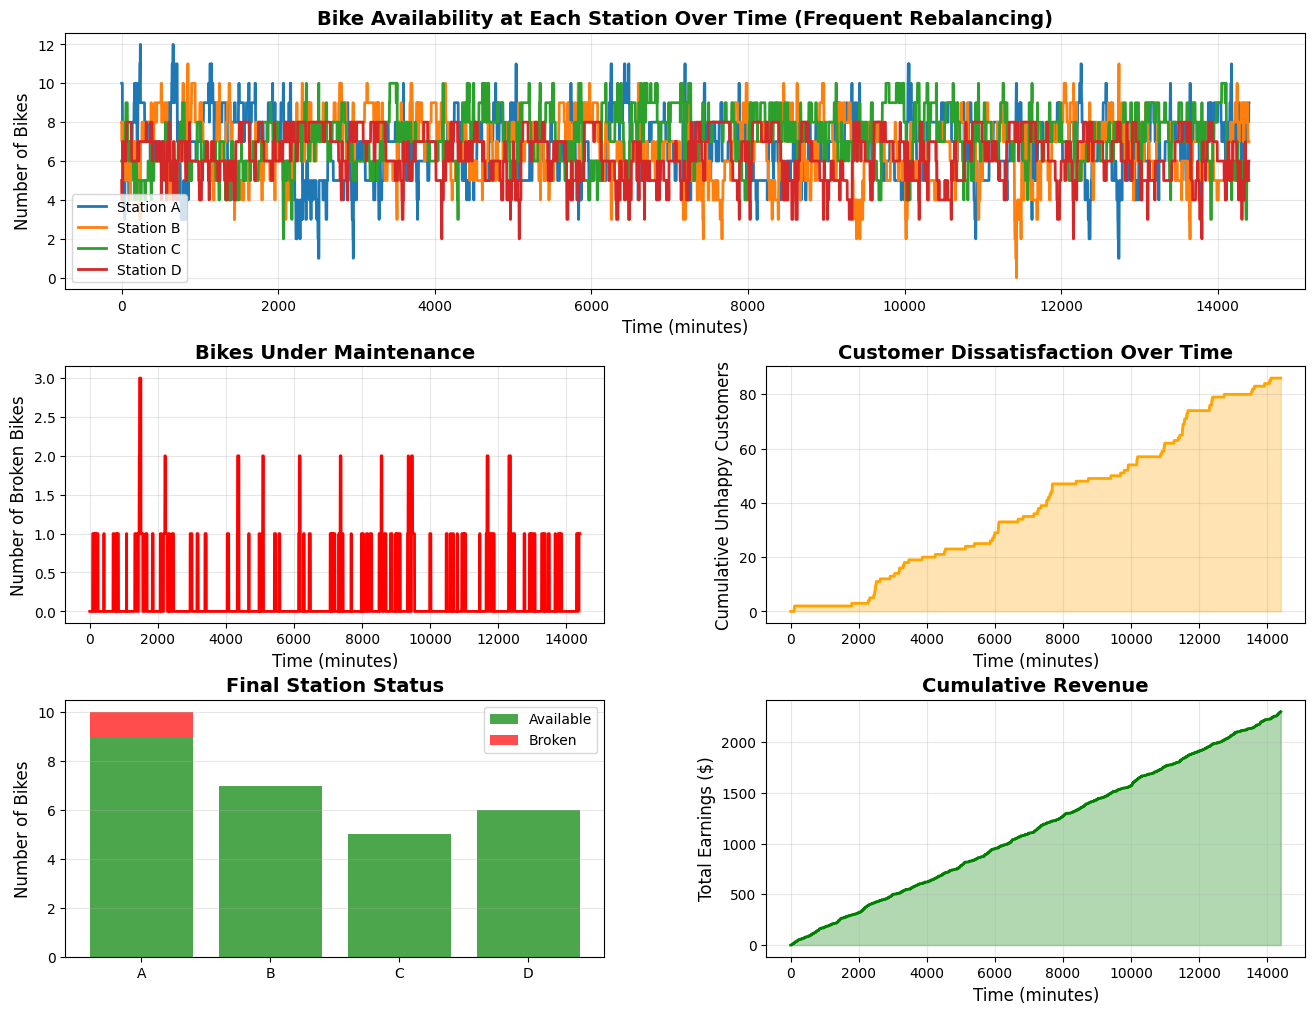

In [25]:
# ============================================================================
# 12. RUN SIMULATIONS (Multiple scenarios for comparison)
# ============================================================================

print("="*70)
print("SCENARIO 1: With Rebalancing and Maintenance")
print("="*70)
results1 = run_bike_sharing_simulation(
    duration=14400,           # 20 days
    with_rebalancing=True,
    with_maintenance=True,
    rebalance_interval=20,
    failure_prob=0.1,
    enable_earnings=True
)
print_summary(results1, 14400)
visualize_results(results1, "(With Rebalancing & Maintenance)")

print("\n" + "="*70)
print("SCENARIO 2: Without Rebalancing")
print("="*70)
results2 = run_bike_sharing_simulation(
    duration=14400,
    with_rebalancing=False,
    with_maintenance=True,
    failure_prob=0.3,
    enable_earnings=True
)
print_summary(results2, 14400)
visualize_results(results2, "(Without Rebalancing)")

print("\n" + "="*70)
print("SCENARIO 3: Increased Rebalancing Frequency")
print("="*70)
results3 = run_bike_sharing_simulation(
    duration=14400,
    with_rebalancing=True,
    with_maintenance=True,
    rebalance_interval=10,    # More frequent
    failure_prob=0.05,
    enable_earnings=True
)
print_summary(results3, 14400)
visualize_results(results3, "(Frequent Rebalancing)")


COMPARATIVE ANALYSIS


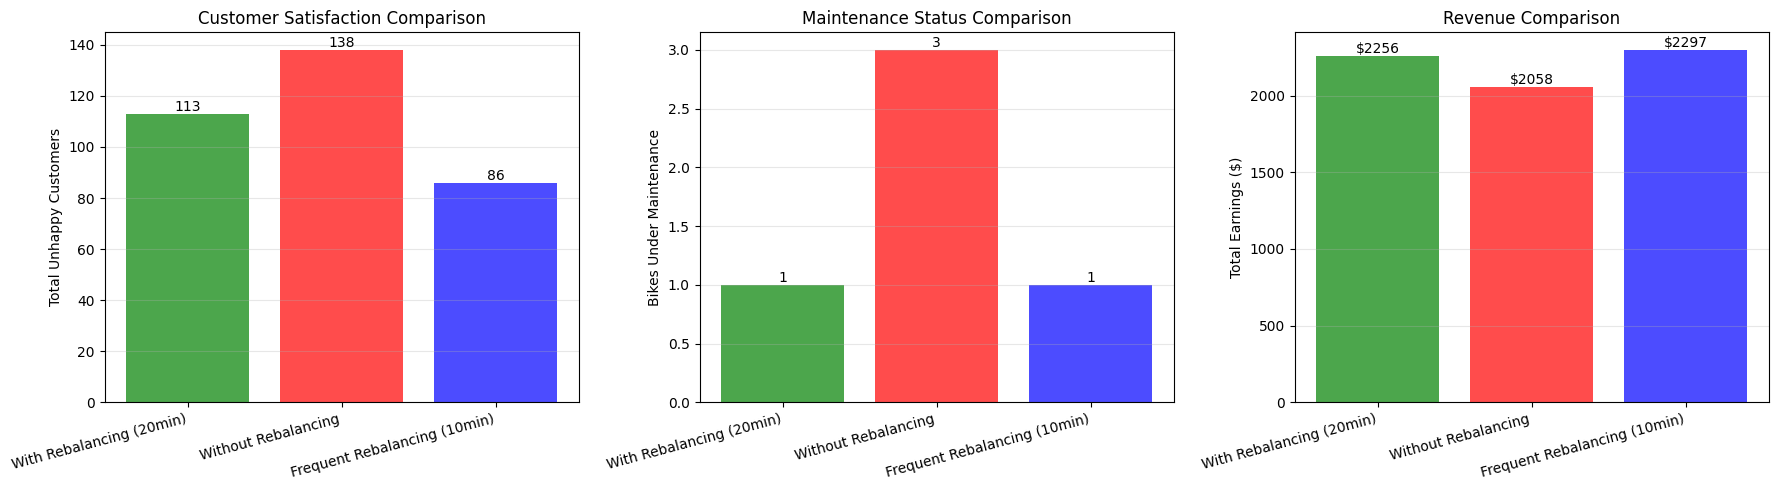

In [26]:
# ============================================================================
# 13. COMPARATIVE ANALYSIS
# ============================================================================
print("\n" + "="*70)
print("COMPARATIVE ANALYSIS")
print("="*70)

scenarios = [
    ("With Rebalancing (20min)", results1),
    ("Without Rebalancing", results2),
    ("Frequent Rebalancing (10min)", results3)
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Compare unhappy customers
ax = axes[0]
unhappy_counts = [r['unhappy_tracker']['pickup_failed'] + r['unhappy_tracker']['return_failed'] 
                  for _, r in scenarios]
colors = ['green', 'red', 'blue']
bars = ax.bar(range(len(scenarios)), unhappy_counts, color=colors, alpha=0.7)
ax.set_xticks(range(len(scenarios)))
ax.set_xticklabels([s[0] for s in scenarios], rotation=15, ha='right')
ax.set_ylabel('Total Unhappy Customers')
ax.set_title('Customer Satisfaction Comparison')
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}', ha='center', va='bottom')

# Compare broken bikes
ax = axes[1]
broken_counts = [sum(s.broken_bikes for s in r['stations']) for _, r in scenarios]
bars = ax.bar(range(len(scenarios)), broken_counts, color=colors, alpha=0.7)
ax.set_xticks(range(len(scenarios)))
ax.set_xticklabels([s[0] for s in scenarios], rotation=15, ha='right')
ax.set_ylabel('Bikes Under Maintenance')
ax.set_title('Maintenance Status Comparison')
ax.grid(True, alpha=0.3, axis='y')

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}', ha='center', va='bottom')

# Compare earnings
ax = axes[2]
earnings = [r['earnings_tracker']['total_earnings'] if r['earnings_tracker'] else 0 
            for _, r in scenarios]
bars = ax.bar(range(len(scenarios)), earnings, color=colors, alpha=0.7)
ax.set_xticks(range(len(scenarios)))
ax.set_xticklabels([s[0] for s in scenarios], rotation=15, ha='right')
ax.set_ylabel('Total Earnings ($)')
ax.set_title('Revenue Comparison')
ax.grid(True, alpha=0.3, axis='y')

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'${int(height)}', ha='center', va='bottom')

plt.tight_layout()
plt.show()